In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
#transforms.ToTensor()  
raw_image =  torchvision.datasets.FashionMNIST('../data/raw', train = True, download = False, transform = None)
tensor_image = torchvision.datasets.FashionMNIST('../data/raw', train = True, download = False, transform = transforms.ToTensor())

In [ ]:
random_sample_list = [1, 10 , 100, 500]
sample_image = []
sample_label = []
for sample_num in random_sample_list:
    image, label = raw_image[sample_num]
    sample_image.append(image)
    sample_label.append(label)
    

In [2]:
test_data = torchvision.datasets.FashionMNIST('../data/raw', train = False, download = False, transform = transforms.ToTensor())

In [ ]:
print(sample_label)

In [ ]:
plt.imshow(sample_image[0], cmap = 'gray')

In [ ]:
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}



In [ ]:
plt.imshow(sample_image[1], cmap = 'gray')

In [ ]:
plt.imshow(sample_image[2], cmap = 'gray')

In [ ]:
plt.imshow(sample_image[3], cmap = 'gray')

In [ ]:
len(raw_image)

In [3]:
train_loader = DataLoader(tensor_image, shuffle = True, batch_size = 64, num_workers = 0)
test_loader = DataLoader(test_data, shuffle =False, batch_size = 64, num_workers = 0)

In [4]:
import numpy as np
import torch.nn as nn


In [ ]:
class CNNModel(nn.Module):
    def __init__(self): 
        super().__init__()

        self.conv_L1 = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels= 6, kernel_size=5,  stride=1, padding=0),
        nn.ReLU(),
        nn.AvgPool2d(kernel_size= 2, stride= 2)
    )
        self.conv_L2 = nn.Sequential(
        nn.Conv2d(in_channels= 6, out_channels = 10, kernel_size=5, stride = 1, padding= 0),
        nn.ReLU(),
        nn.AvgPool2d(kernel_size=2, stride=2)
    )
        self.flatten = nn.Flatten()
        self.fc_block = nn.Sequential(
        nn.Linear(4*4*10, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
    )

    def forward(self, x):
        x = self.conv_L1(x)
        x = self.conv_L2(x)
        x = self.flatten(x)
        x = self.fc_block(x)
        return x
        

In [5]:
class DynamicCNN(nn.Module):
    def __init__(self, H, W, conv_config, fc_config, num_classes):
        super(DynamicCNN, self).__init__()
        conv_layers = []
        conv_nc = []
        d_in = 1
        for layer_info in conv_config:
            nc, f, s, p = layer_info
            conv_layers.append(nn.Conv2d(in_channels = d_in, out_channels = nc, kernel_size = f, stride = s, padding = p))
            conv_layers.append(nn.ReLU())
            H = (( H - f + (2*p)) // s) + 1
            W = (( W - f + (2*p)) // s) + 1
            conv_layers.append(nn.AvgPool2d(kernel_size = 2, stride = 2))
            H //= 2
            W //= 2
            d_in = nc
            conv_nc.append(nc)

        conv_layers.append(nn.Flatten())
        previous_neurons = conv_nc[-1] * H * W
        for fc in fc_config:
            conv_layers.append(nn.Linear(previous_neurons, fc))
            conv_layers.append(nn.ReLU())
            previous_neurons = fc
            
        conv_layers.append(nn.Linear(previous_neurons, num_classes))
        self.network = nn.Sequential(*conv_layers)

    def forward(self, x):
        return self.network(x)

In [6]:
im, lab = tensor_image[0]
print(im.shape)

torch.Size([1, 28, 28])


In [7]:
C, H, W = im.shape
conv_config = [
    (6,5,1,0), (10,5,1, 0)
]
fc_config = [120, 84]

In [8]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DynamicCNN(H, W, conv_config, fc_config, 10 )
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 1e-4)

In [9]:
N_epochs = 50

In [12]:
train_losses = []
val_losses = []
for epoch in range(N_epochs):
    model.train()
    epoch_train_loss= 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss/ len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            val_prediction = model(X_batch)
            val_loss = criterion(val_prediction, y_batch)

            epoch_val_loss += val_loss.item()

        avg_val_loss = epoch_val_loss/len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"for epoch {epoch+1}|{N_epochs}, training_loss: {avg_train_loss:.4f} and validation_loss: {avg_val_loss:.4f}")

for epoch 1|50, training_loss: 0.7594 and validation_loss: 0.7402
for epoch 2|50, training_loss: 0.6996 and validation_loss: 0.6921
for epoch 3|50, training_loss: 0.6662 and validation_loss: 0.6674
for epoch 4|50, training_loss: 0.6402 and validation_loss: 0.6707
for epoch 5|50, training_loss: 0.6185 and validation_loss: 0.6374
for epoch 6|50, training_loss: 0.5977 and validation_loss: 0.6095
for epoch 7|50, training_loss: 0.5794 and validation_loss: 0.6079
for epoch 8|50, training_loss: 0.5629 and validation_loss: 0.5831
for epoch 9|50, training_loss: 0.5496 and validation_loss: 0.5751
for epoch 10|50, training_loss: 0.5361 and validation_loss: 0.5607
for epoch 11|50, training_loss: 0.5249 and validation_loss: 0.5832
for epoch 12|50, training_loss: 0.5143 and validation_loss: 0.5408
for epoch 13|50, training_loss: 0.5030 and validation_loss: 0.5334
for epoch 14|50, training_loss: 0.4917 and validation_loss: 0.5199
for epoch 15|50, training_loss: 0.4828 and validation_loss: 0.5066
for 

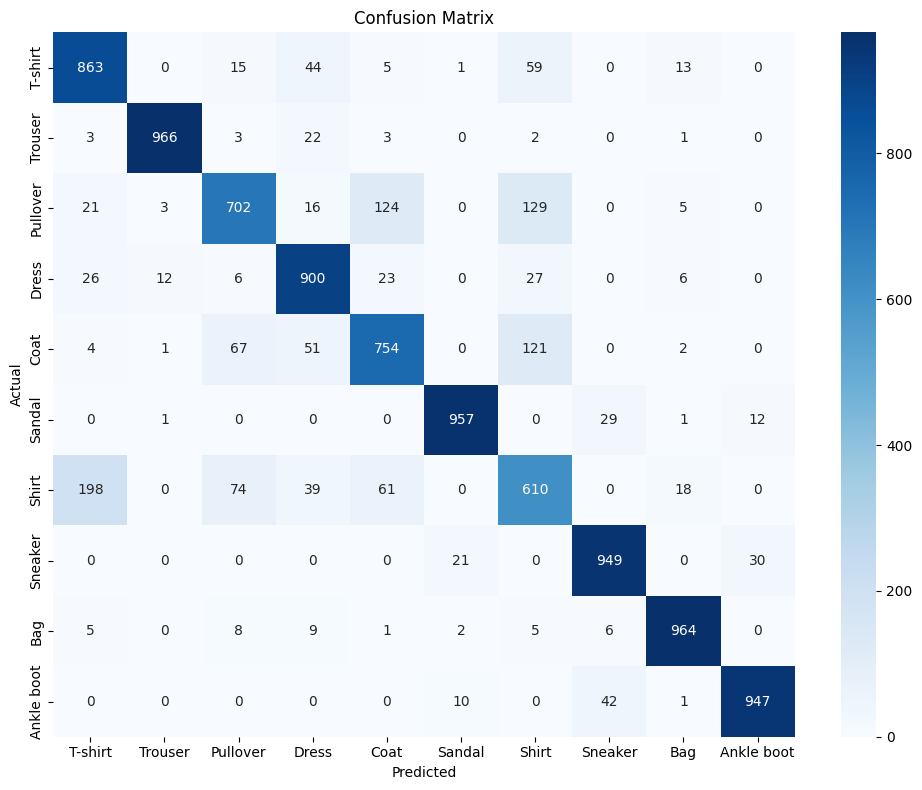

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fashion_mnist_labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_mnist_labels,
            yticklabels=fashion_mnist_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix.png')
plt.show()

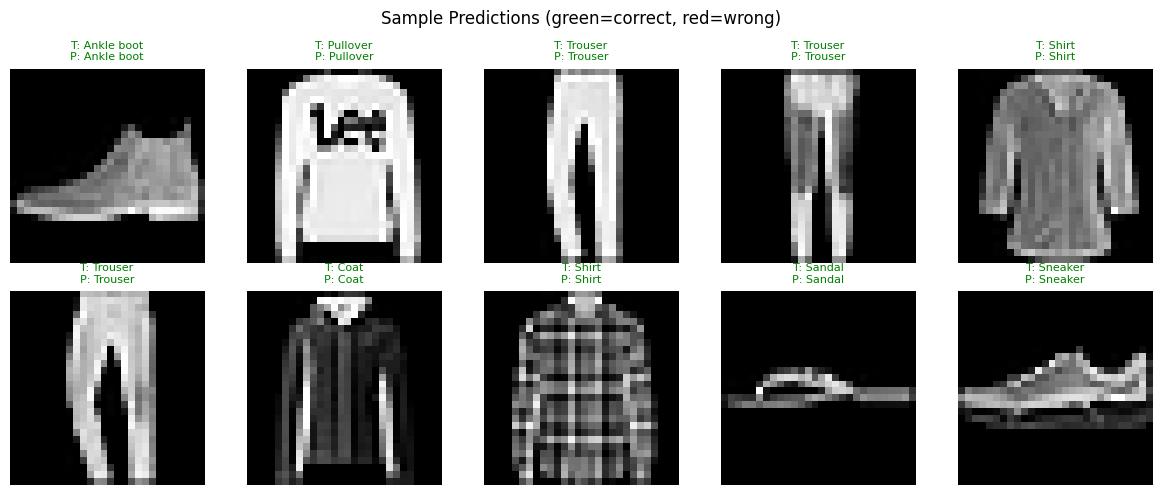

In [14]:
model.eval()
images_shown = 0
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        outputs = model(x_batch)
        _, preds = torch.max(outputs, 1)

        for i in range(x_batch.size(0)):
            if images_shown >= 10:
                break
            ax = axes[images_shown]
            ax.imshow(x_batch[i].cpu().squeeze(), cmap='gray')
            true  = fashion_mnist_labels[y_batch[i]]
            pred  = fashion_mnist_labels[preds[i].cpu()]
            color = 'green' if true == pred else 'red'
            ax.set_title(f'T: {true}\nP: {pred}', color=color, fontsize=8)
            ax.axis('off')
            images_shown += 1

        if images_shown >= 10:
            break

plt.suptitle('Sample Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.savefig('../results/plots/sample_predictions.png')
plt.show()
